# Tuning of `window` and `precip_jump_factor` (BLSN algorithm)

Reference for cloud/precipitation independent of the ceilometer:
- precip: MRR, SNR > 0 dB over ≥ 3 consecutive range gates for ≥ 10 min
- cloud: apparent sky emissivity $\varepsilon = LW_{down}/(\sigma T_a^4)$, cloudy if $\varepsilon > \varepsilon_{Otsu}$

Expected peak (cat2/3) = precip OR cloud. Data split 80/20 (validation/test), grouped by day.

In [9]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
%matplotlib inline

# ---- paths ----
CEIL_2024 = 'D:/data/ceilo/2024'
CEIL_2025 = 'D:/data/ceilo/2025'
BLSN_CSV  = ['C:\\Users\\lory2\\Desktop\\thesis_codes\\03_ceilometer_bs_detection\\ceilo_alg_results_2024.csv', 'C:\\Users\\lory2\\Desktop\\thesis_codes\\03_ceilometer_bs_detection\\ceilo_alg_results_2025.csv']  # official algorithm output
CEIL_CLR  = r'D:\data\clear_sky_profile_bin1_21.csv'
MRR_CSV   = r'D:\mrr_precip_timestamps_labeled.csv'
SLOW      = [r'D:\data\slowdata_cleaned\slowdata_cleaned_2024.pkl',
             r'D:\data\slowdata_cleaned\slowdata_cleaned_2025.pkl']
CACHE     = r'D:\ceilo_candidate_profiles_full.npz'   # cache of full profiles
PRED_PKL  = r'D:\blsn_pred_grid.pkl'                   # cache of (window, factor) predictions

AVG = '5min'
DEF = dict(window=3, pjf=0.25, cat3=10000.0, wind_thres=3.0, rh_thres=90.0)   # algorithm defaults

ceil_clr = pd.read_csv(CEIL_CLR, header=None).values[0]

## 1. Categorization function

In [10]:
def categorize_profile(prof, ceil_clr, height, crit1, crit2, crit3, crit5,
                       window=3, precip_jump_factor=0.25, cat3_thr=10000.0):
    # Return (category, top_height)
    cat = 0
    idx = 0
    crit4 = 1  # visibility criterion deactivated
    if crit1 + crit2 + crit3 + crit4 + crit5 == 5:
        idx = 1
        local_min = prof[1]
        local_min_idx = 1
        while idx < len(height) - 2:
            if np.isfinite(prof[idx]) and prof[idx] < local_min:
                local_min = prof[idx]; local_min_idx = idx
            # (a) below clear-sky -> top found
            if prof[idx] < ceil_clr[idx]:
                break
            # (b) risen from local minimum -> cat2
            if np.isfinite(prof[idx]) and local_min > 0:
                if prof[idx] > local_min * (1 + precip_jump_factor):
                    idx = local_min_idx; break
            idx += 1
        # single-bin noise check on the lowest bins
        if idx < 10 and idx < len(height) - 5:
            if prof[idx] >= np.nanmean(prof[idx + 2:idx + 5]):
                idx += 1
                while idx < len(height) - 2:
                    if prof[idx] <= prof[idx + 1]:
                        break
                    if prof[idx] < ceil_clr[idx]:
                        break
                    idx += 1
        cat = 1 if prof[idx + 1] < ceil_clr[idx + 1] else 2
        if prof[1] >= cat3_thr:
            cat = 3
    if (crit1 + crit2 + crit3 + crit4 == 4) and (crit5 == 0):
        cat = 4
    elif crit1 + crit2 + crit3 + crit4 + crit5 != 5 and cat != 4:
        cat = 0
    top = height[idx] if idx > 0 else 99999999.9
    return cat, top

## 2. Data: official CSV (criteria, wind, RH) and ceilometer profiles

In [11]:
df = pd.concat([pd.read_csv(f) for f in BLSN_CSV], ignore_index=True)
df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
df = df.replace(99999999.9, np.nan)
df = df[~df['datetime'].duplicated()].set_index('datetime').sort_index()
print('CSV rows:', len(df))

CSV rows: 131671


In [12]:
# full profiles (negatives -> NaN, 5-min mean), only days with BLSN events; cached
if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    profiles = z['profiles']; ptimes = pd.DatetimeIndex(z['times']); height = z['height']
else:
    blsn_days = pd.Index(df[df['category'].isin([1, 2, 3, 4])].index.normalize().unique())
    want = set(df.index)
    mats, times_list, height = [], [], None
    files = sorted(list(Path(CEIL_2024).rglob('peaceilCL31.b1.*.nc')) + list(Path(CEIL_2025).rglob('peaceilCL31.b1.*.nc')))
    for f in files:
        d = f.name.split('.')[2]
        if pd.to_datetime(d).normalize() not in blsn_days:
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore'); ds = xr.open_dataset(f, decode_times=False)
            bs = ds['backscatter']
            if bs.dims[0] != 'time':
                bs = bs.transpose('time', 'range')
            t = pd.to_datetime(d) + pd.to_timedelta(ds['time'].values, unit='h')
            bs = bs.assign_coords(time=t).sortby('time').where(lambda x: x > 0)
            r = bs.resample(time=AVG, label='left', closed='left').mean()
            rt = pd.to_datetime(r['time'].values)
            keep = rt.isin(want)
            if keep.any():
                mats.append(r.values[keep].astype('float32')); times_list.append(rt[keep])
            if height is None:
                height = ds['range'].values
            ds.close()
        except Exception as e:
            print(d, 'error', e)
    profiles = np.vstack(mats)
    ptimes = pd.DatetimeIndex(np.concatenate([t.values for t in times_list]))
    o = np.argsort(ptimes.values); profiles, ptimes = profiles[o], ptimes[o]
    keep = ~ptimes.duplicated(); profiles, ptimes = profiles[keep], ptimes[keep]
    np.savez_compressed(CACHE, profiles=profiles, times=ptimes.values, height=height)
print('profiles:', profiles.shape, '| height bins:', len(height))

sub = df.reindex(ptimes)
crit1 = sub['decreasing_profile'].fillna(0).astype(int).values
crit2 = sub['above_clear_sky'].fillna(0).astype(int).values
wind  = sub['10m_windspeed'].values
rh    = sub['2m_rel_hum'].values

def run_all(window, pjf, cat3=DEF['cat3'], wind_thres=DEF['wind_thres'], rh_thres=DEF['rh_thres']):
    # only crit1 & crit2 & wind>thr profiles can get a non-zero category
    c3 = (np.nan_to_num(wind, nan=-1) > wind_thres).astype(int)
    c5 = (np.nan_to_num(rh, nan=1e9) < rh_thres).astype(int)
    active = (crit1 == 1) & (crit2 == 1) & (c3 == 1)
    cats = np.zeros(len(ptimes), int)
    tops = np.full(len(ptimes), 99999999.9)
    for i in np.flatnonzero(active):
        cats[i], tops[i] = categorize_profile(profiles[i], ceil_clr, height,
                                              crit1[i], crit2[i], int(c3[i]), int(c5[i]),
                                              window=window, precip_jump_factor=pjf, cat3_thr=cat3)
    return cats, tops

profiles: (54258, 770) | height bins: 770


## 3. Reference: cloud from sky emissivity (Otsu threshold) and precipitation from MRR

Otsu threshold: eps = 0.755


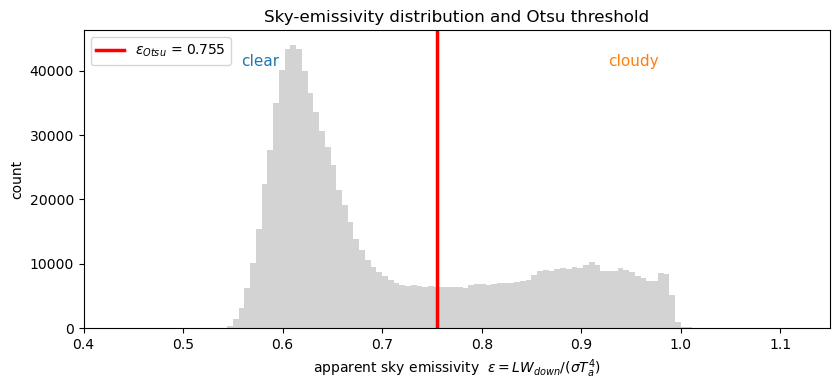

cloud: 57% | precip: 27% | peak_expected: 57%


In [13]:
SIGMA = 5.670374e-8
sl = pd.concat([pd.read_pickle(pp) for pp in SLOW])
sl = sl[~sl.index.duplicated()].sort_index()
eps_all = sl['LWdown1'].values / (SIGMA * (sl['TA'].values + 273.15)**4)
eps_series = pd.Series(eps_all, index=sl.index)

def otsu_threshold(x, bins=200):
    x = x[np.isfinite(x)]
    lo, hi = np.percentile(x, 0.5), np.percentile(x, 99.5)
    hist, edges = np.histogram(x, bins=bins, range=(lo, hi))
    pk = hist / hist.sum()
    centers = 0.5 * (edges[:-1] + edges[1:])
    omega = np.cumsum(pk); mu = np.cumsum(pk * centers); mu_t = mu[-1]
    denom = omega * (1 - omega)
    sigma_b = np.where(denom > 0, (mu_t * omega - mu)**2 / denom, 0.0)
    return centers[np.argmax(sigma_b)]

EPS_OTSU = otsu_threshold(eps_all)
print(f'Otsu threshold: eps = {EPS_OTSU:.3f}')

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(eps_all[np.isfinite(eps_all)], bins=130, range=(0.4, 1.15), color='lightgray')
ax.axvline(EPS_OTSU, color='red', lw=2.5, label=rf'$\varepsilon_{{Otsu}}$ = {EPS_OTSU:.3f}')
ymax = ax.get_ylim()[1]
ax.text((0.40 + EPS_OTSU)/2, ymax*0.92, 'clear', ha='center', va='top', color='tab:blue', fontsize=11)
ax.text((EPS_OTSU + 1.15)/2, ymax*0.92, 'cloudy', ha='center', va='top', color='tab:orange', fontsize=11)
ax.set_xlabel(r'apparent sky emissivity  $\varepsilon = LW_{down}/(\sigma T_a^4)$')
ax.set_ylabel('count'); ax.set_xlim(0.40, 1.15)
ax.set_title('Sky-emissivity distribution and Otsu threshold')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

# labels on the BLSN timestamps
emis = eps_series.reindex(ptimes, method='nearest', tolerance=pd.Timedelta('3min')).values
mrr = pd.read_csv(MRR_CSV, parse_dates=['time']).set_index('time').sort_index()
mrr = mrr[~mrr.index.duplicated()]
precip = mrr['label'].reindex(ptimes, method='nearest', tolerance=pd.Timedelta('3min')).notna().values
cloud = emis > EPS_OTSU
peak_expected = precip | cloud
print(f'cloud: {np.nanmean(cloud)*100:.0f}% | precip: {precip.mean()*100:.0f}% '
      f'| peak_expected: {peak_expected.mean()*100:.0f}%')

## 4. Validation / test split (80/20, by day) and selection of `window`, `precip_jump_factor`

validation / test days: 162 / 41
window      2      3
factor              
0.10    0.911  0.911
0.15    0.904  0.904
0.20    0.897  0.897
0.25    0.892  0.892
0.30    0.887  0.887
0.35    0.882  0.882
0.40    0.878  0.878

SELECTED: window=3, precip_jump_factor=0.1  (validation F1=0.911)


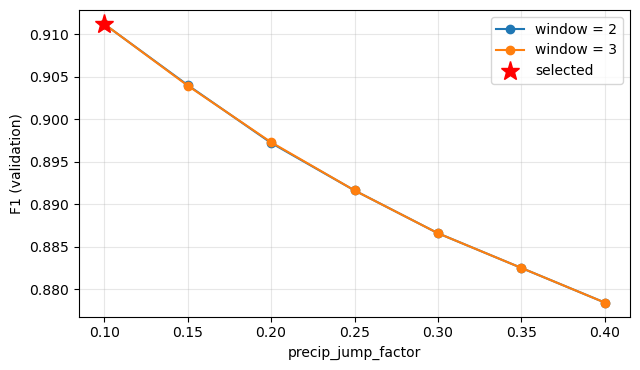

TEST F1 selected: 0.929 | default (3, 0.25): 0.93


In [14]:
rng = np.random.default_rng(42)
days = ptimes.normalize().values
udays = np.unique(days); rng.shuffle(udays)
test_days = udays[:int(round(0.20 * len(udays)))]
is_test = np.isin(days, test_days)
is_val = ~is_test
print('validation / test days:', len(udays) - len(test_days), '/', len(test_days))

def confusion(cats, y, mask):
    # positive = peak (cat2/3); only where the algorithm detects BLSN (cat1/2/3)
    blsn = np.isin(cats, [1, 2, 3]) & mask
    pred = np.isin(cats, [2, 3])[blsn]; true = y[blsn]
    TP = int(np.sum(pred & true));  FP = int(np.sum(pred & ~true))
    FN = int(np.sum(~pred & true)); TN = int(np.sum(~pred & ~true))
    return TP, FP, FN, TN

def f1_peak(cats, y, mask):
    TP, FP, FN, TN = confusion(cats, y, mask)
    return 2*TP / (2*TP + FP + FN) if TP else 0.0

# grid of predictions (cached)
windows = [2, 3]
factors = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
PRED = pickle.load(open(PRED_PKL, 'rb')) if os.path.exists(PRED_PKL) else {}
missing = [(w, f) for w in windows for f in factors if (w, f) not in PRED]
for (w, f) in missing:
    PRED[(w, f)] = run_all(w, f)
if missing:
    pickle.dump(PRED, open(PRED_PKL, 'wb'))

# selection on the validation set
res = pd.DataFrame([dict(window=w, factor=f, val_F1=f1_peak(PRED[(w, f)][0], peak_expected, is_val))
                    for w in windows for f in factors])
best = res.sort_values('val_F1', ascending=False).iloc[0]
BW, BF = int(best.window), float(best.factor)
print(res.pivot(index='factor', columns='window', values='val_F1').round(3).to_string())
print(f'\nSELECTED: window={BW}, precip_jump_factor={BF}  (validation F1={best.val_F1:.3f})')

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for w in windows:
    s = res[res.window == w]
    ax.plot(s.factor, s.val_F1, marker='o', label=f'window = {w}')
ax.plot(BF, best.val_F1, 'r*', ms=14, label='selected')
ax.set_xlabel('precip_jump_factor'); ax.set_ylabel('F1 (validation)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

cats_best, tops_best = PRED[(BW, BF)]
print('TEST F1 selected:', round(f1_peak(cats_best, peak_expected, is_test), 3),
      '| default (3, 0.25):', round(f1_peak(PRED[(3, 0.25)][0], peak_expected, is_test), 3))

## 5. Confusion matrix (test set)

window=3, factor=0.1 | n=1571
accuracy=0.899  precision=0.934  recall=0.925  specificity=0.832  F1=0.929  balanced_acc=0.878  MCC=0.751


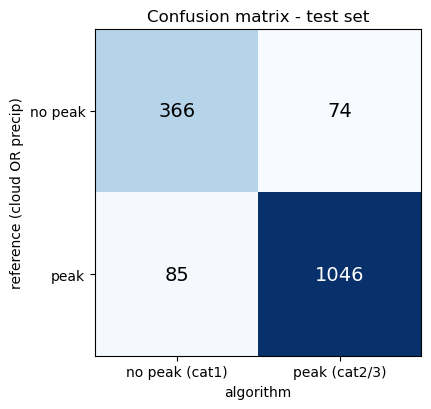

In [15]:
TP, FP, FN, TN = confusion(cats_best, peak_expected, is_test)
cm = np.array([[TN, FP], [FN, TP]])
prec = TP/(TP+FP) if TP+FP else 0; rec = TP/(TP+FN) if TP+FN else 0
spec = TN/(TN+FP) if TN+FP else 0
f1 = 2*prec*rec/(prec+rec) if prec+rec else 0
den = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)); mcc = (TP*TN - FP*FN)/den if den else 0
print(f'window={BW}, factor={BF} | n={cm.sum()}')
print(f'accuracy={(TP+TN)/cm.sum():.3f}  precision={prec:.3f}  recall={rec:.3f}  specificity={spec:.3f}  '
      f'F1={f1:.3f}  balanced_acc={0.5*(rec+spec):.3f}  MCC={mcc:.3f}')

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['no peak (cat1)', 'peak (cat2/3)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['no peak', 'peak'])
ax.set_xlabel('algorithm'); ax.set_ylabel('reference (cloud OR precip)')
ax.set_title('Confusion matrix - test set')
for r in range(2):
    for c in range(2):
        ax.text(c, r, cm[r, c], ha='center', va='center', fontsize=14,
                color='white' if cm[r, c] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

## 6. Case studies: backscatter minus clear-sky profile and BLSN top (original vs new algorithm)

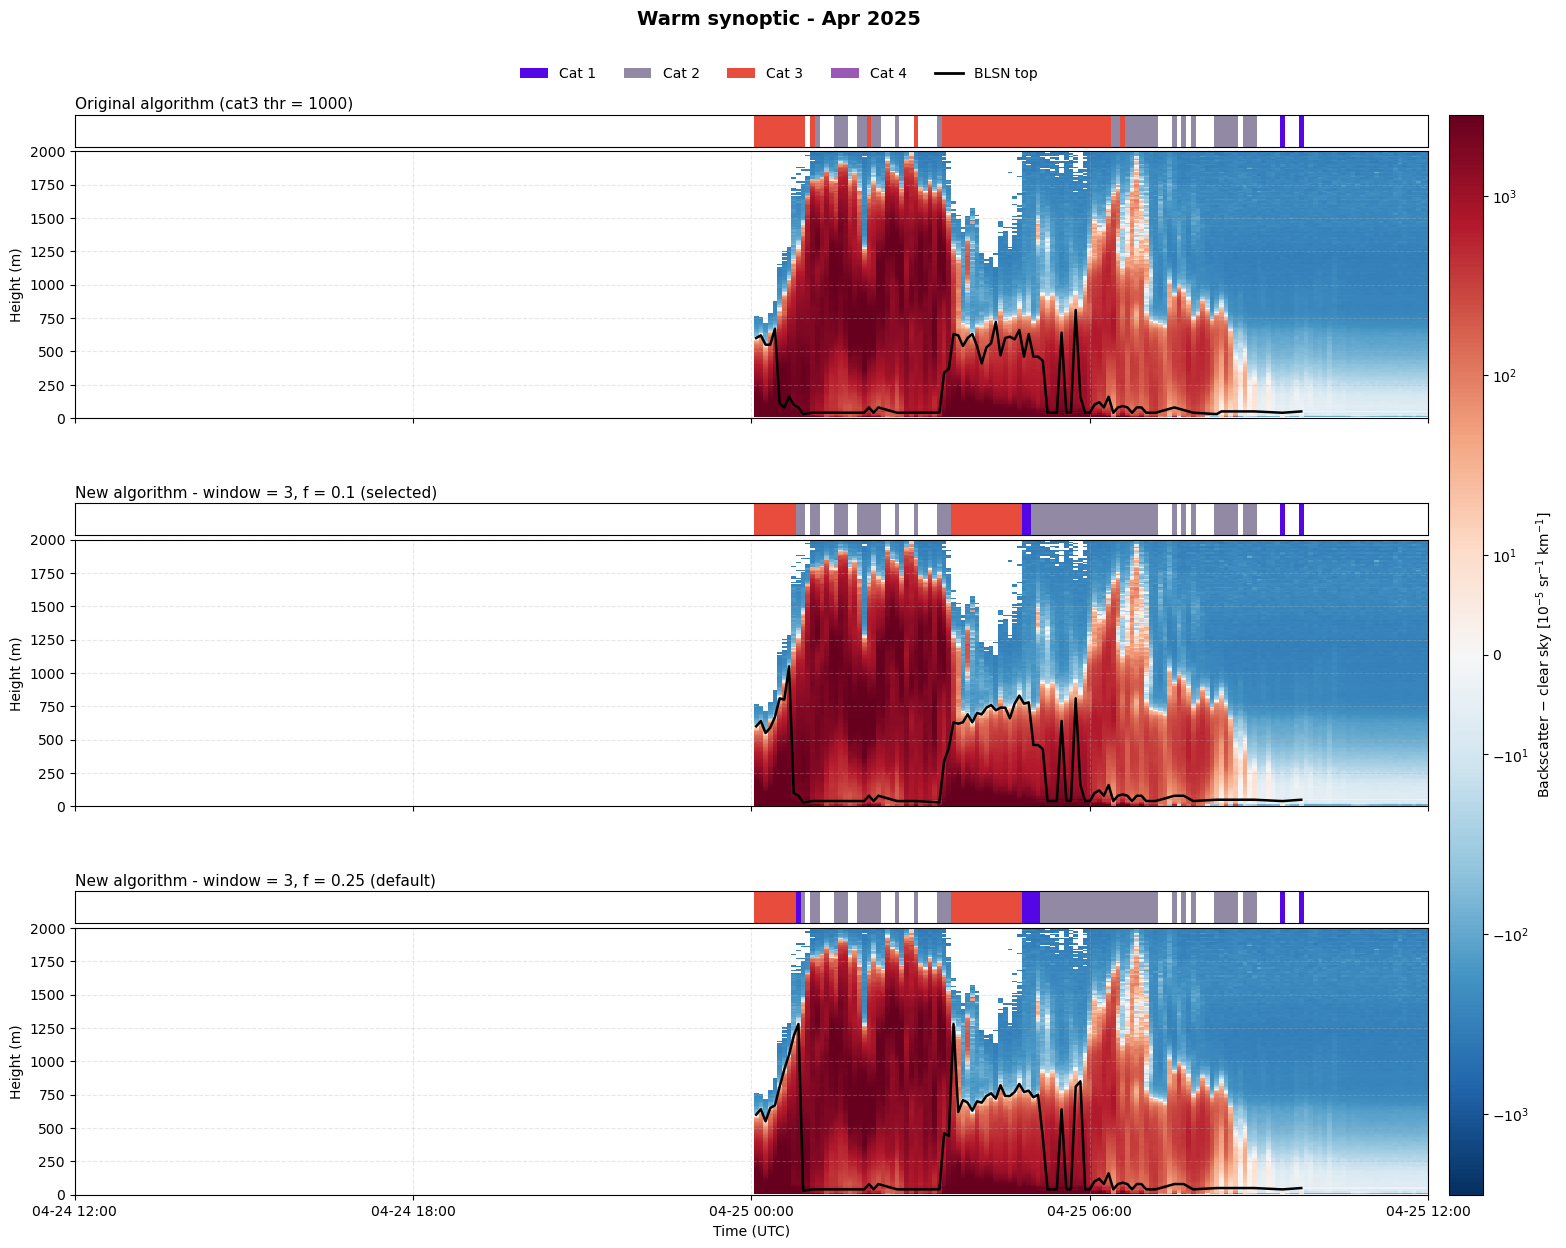

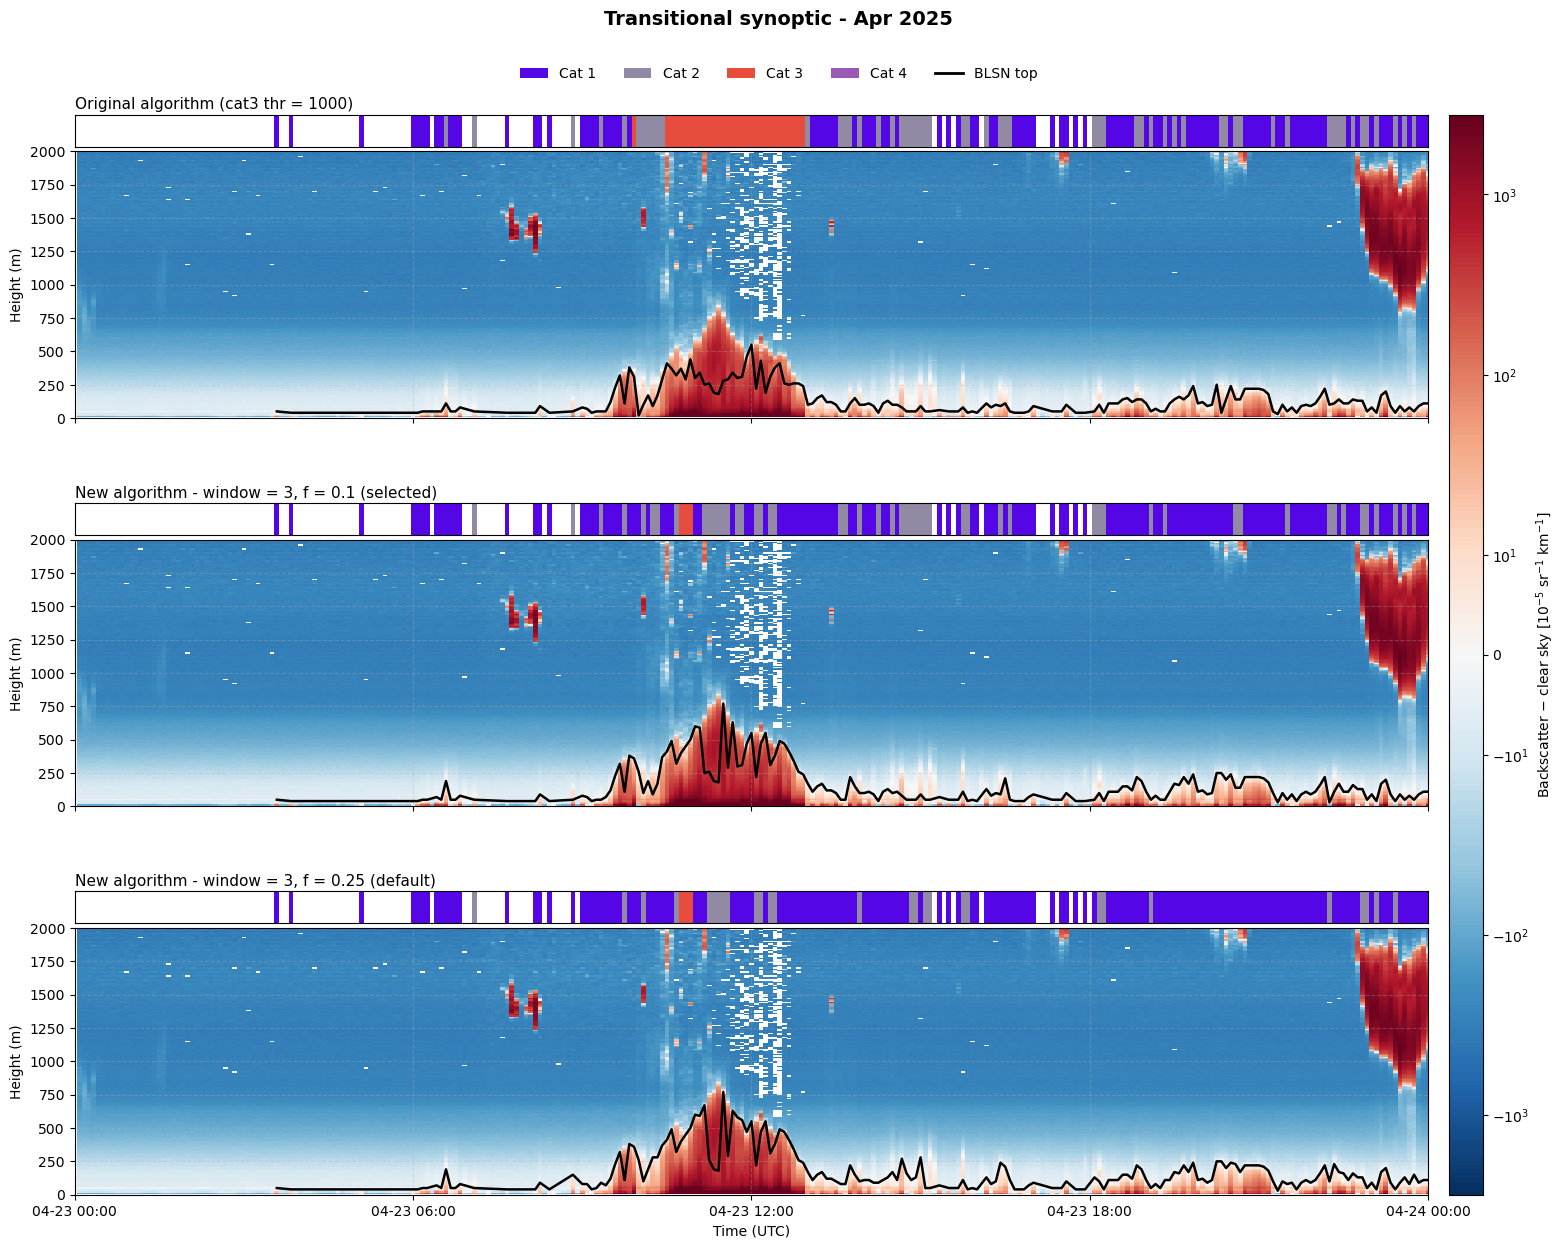

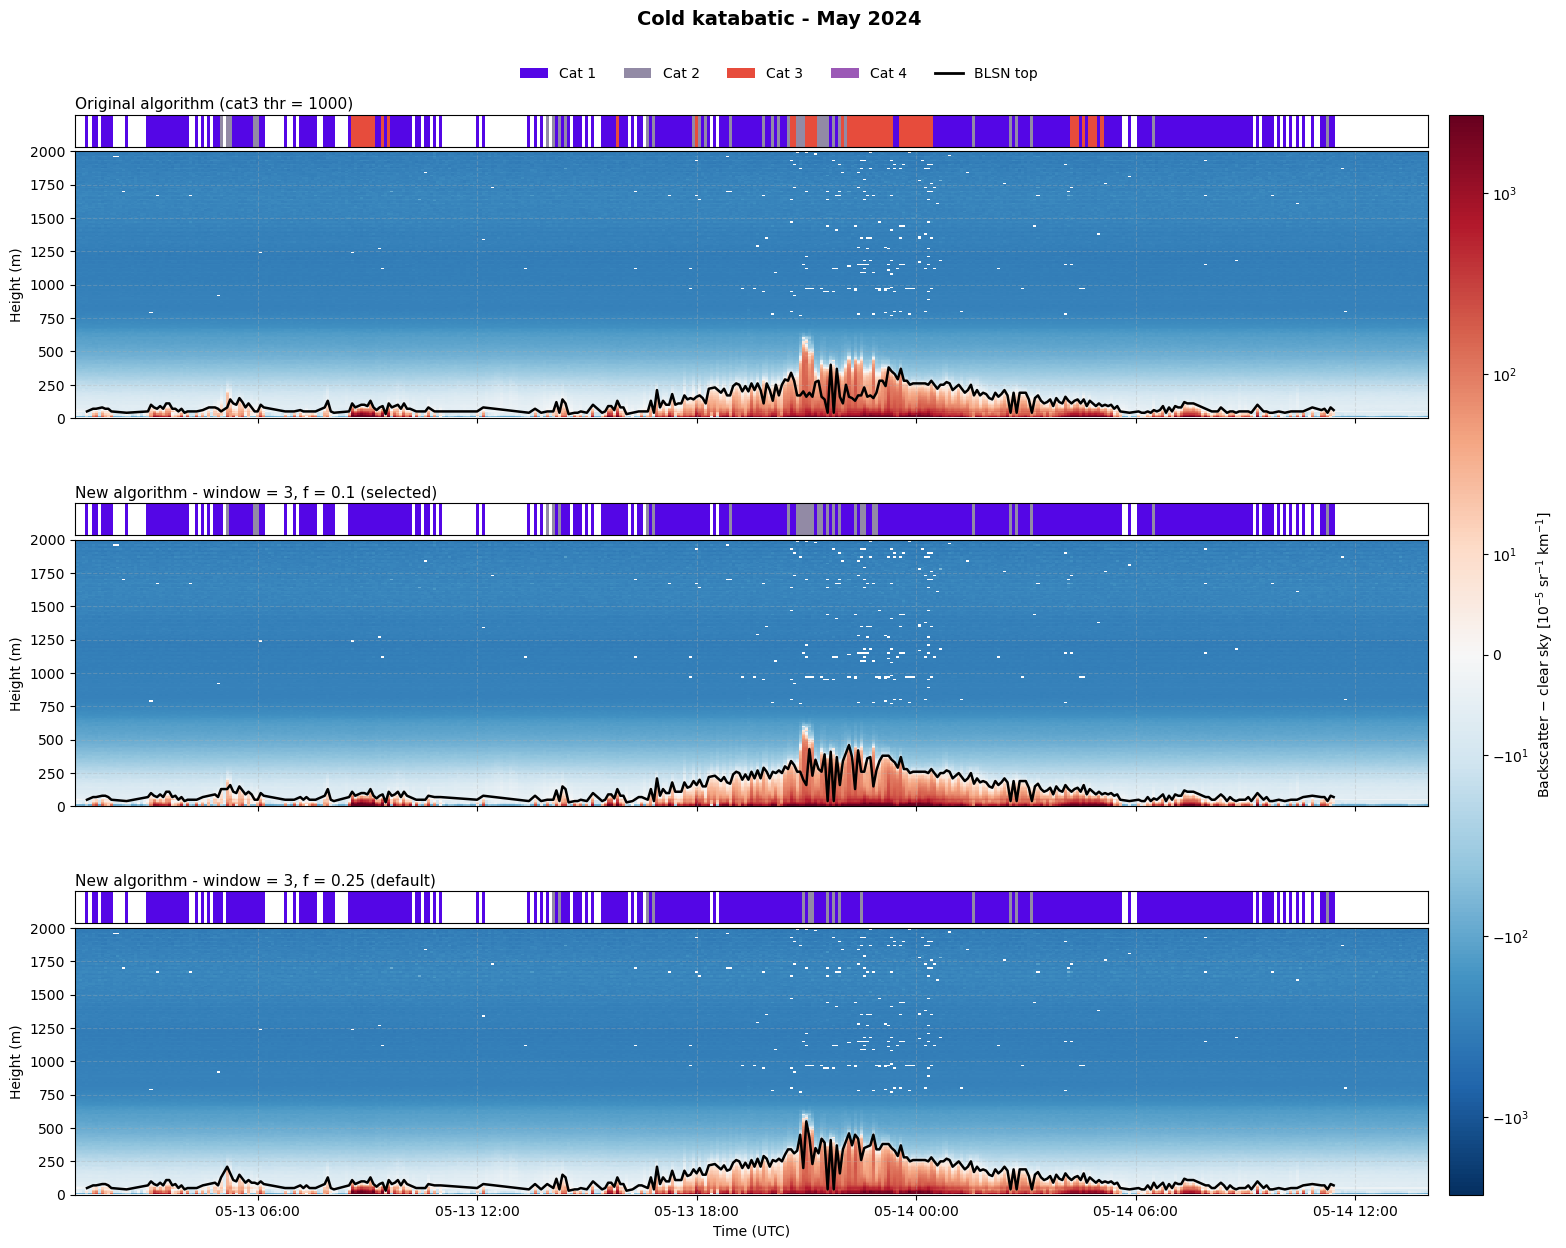

In [16]:
EVENTS = {
    "Warm synoptic - Apr 2025": dict(start="2025-04-24 12:00", end="2025-04-25 12:00", ceil_path=CEIL_2025),
    "Transitional synoptic - Apr 2025": dict(start="2025-04-23 00:00", end="2025-04-24 00:00", ceil_path=CEIL_2025),
    "Cold katabatic - May 2024": dict(start="2024-05-13 01:00", end="2024-05-14 14:00", ceil_path=CEIL_2024),
}
CAT_COLORS = {0: "white", 1: "#5406E6", 2: "#928aa5", 3: "#e74c3c", 4: "#9b59b6"}

def load_ceilo_event(ceil_path, t_start, t_end):
    mats, tlist, h = [], [], None
    for d in pd.date_range(pd.Timestamp(t_start).floor("D"), pd.Timestamp(t_end).floor("D"), freq="D"):
        ds_str = d.strftime("%Y%m%d")
        matches = sorted(Path(ceil_path).joinpath(d.strftime("%Y%m")).glob(f"peaceilCL31.b1.{ds_str}*.nc"))
        if not matches:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore"); ds = xr.open_dataset(matches[0], decode_times=False)
        bs = ds["backscatter"]
        if bs.dims[0] != "time":
            bs = bs.transpose("time", "range")
        t = pd.to_datetime(ds_str) + pd.to_timedelta(ds["time"].values, unit="h")
        bs = bs.assign_coords(time=t).sortby("time").where(lambda x: x > 0)
        r = bs.resample(time="5min", label="left", closed="left").mean()
        rt = pd.to_datetime(r["time"].values)
        m = (rt >= pd.Timestamp(t_start)) & (rt <= pd.Timestamp(t_end))
        if m.any():
            mats.append(r.values[m].astype("float32")); tlist.append(rt[m])
        if h is None:
            h = ds["range"].values
        ds.close()
    if not mats:
        return None, None, None
    return pd.DatetimeIndex(np.concatenate([x.values for x in tlist])), h, np.vstack(mats)

def categorize_original(prof, h, c1, c2, c3, c5, clr):
    # original ascent: stops at the first non-strictly-decreasing step; cat3 thr = 1000
    cat = 0; idx = 0; crit4 = 1
    if c1 + c2 + c3 + crit4 + c5 == 5:
        idx = 1
        while idx < len(h) - 2:
            if prof[idx] <= prof[idx + 1] or prof[idx] < clr[idx]:
                break
            idx += 1
        if idx < 10 and idx < len(h) - 5:
            if prof[idx] >= np.nanmean(prof[idx+2:idx+5]):
                idx += 1
                while idx < len(h) - 2:
                    if prof[idx] <= prof[idx+1] or prof[idx] < clr[idx]:
                        break
                    idx += 1
        cat = 1 if prof[idx+1] < clr[idx+1] else 2
        if prof[1] >= 1000.:
            cat = 3
    if (c1+c2+c3+crit4 == 4) and (c5 == 0): cat = 4
    elif c1+c2+c3+crit4+c5 != 5 and cat != 4: cat = 0
    return cat, (h[idx] if idx > 0 else 99999999.9)

lkp = pd.Series(np.arange(len(ptimes)), index=ptimes)
c3_arr = (np.nan_to_num(wind, nan=-1) > DEF["wind_thres"]).astype(int)
c5_arr = (np.nan_to_num(rh, nan=1e9) < DEF["rh_thres"]).astype(int)

def event_original(t_arr):
    matched = lkp.reindex(t_arr, method="nearest", tolerance=pd.Timedelta("3min")).values
    cats = np.zeros(len(t_arr), int); tops = np.full(len(t_arr), 99999999.9)
    for j, ip in enumerate(matched):
        if np.isnan(ip): continue
        ip = int(ip)
        cats[j], tops[j] = categorize_original(profiles[ip], height, crit1[ip], crit2[ip],
                                               int(c3_arr[ip]), int(c5_arr[ip]), ceil_clr)
    return cats, tops

def event_new(t_arr, window, factor):
    cats, tops = PRED[(window, factor)]
    tol = pd.Timedelta("3min")
    c = pd.Series(cats.astype(float), index=ptimes).reindex(t_arr, method="nearest", tolerance=tol).fillna(0).astype(int).values
    t = pd.Series(tops, index=ptimes).reindex(t_arr, method="nearest", tolerance=tol).values
    return c, t

CONFIGS = [("Original algorithm (cat3 thr = 1000)", lambda t: event_original(t))]
for f in dict.fromkeys([BF, DEF['pjf']]):   # selected + default (no duplicates)
    tag = 'selected' if f == BF else 'default'
    CONFIGS.append((f"New algorithm - window = {BW}, f = {f} ({tag})", lambda t, f=f: event_new(t, BW, f)))

legend_handles = [mpatches.Patch(facecolor=CAT_COLORS[i], label=f"Cat {i}") for i in [1, 2, 3, 4]] + \
                 [Line2D([0], [0], color="black", lw=2, label="BLSN top")]

for label, ev in EVENTS.items():
    t_arr, ht, bsc = load_ceilo_event(ev["ceil_path"], ev["start"], ev["end"])
    if t_arr is None:
        print(label, ": no data"); continue
    t_num = mdates.date2num(t_arr)
    t_s, t_e = mdates.date2num(pd.Timestamp(ev["start"])), mdates.date2num(pd.Timestamp(ev["end"]))
    # backscatter minus clear-sky profile (per bin); > 0 = above clear sky
    clr = np.full(len(ht), np.nan); nc = min(len(ht), len(ceil_clr)); clr[:nc] = ceil_clr[:nc]
    anom = (bsc - clr[None, :]).T                       # (height, time)
    vmax = float(np.nanpercentile(np.abs(anom[np.isfinite(anom)]), 99))
    norm = mcolors.SymLogNorm(linthresh=10, linscale=0.5, vmin=-vmax, vmax=vmax, base=10)
    w_bar = (t_num[1] - t_num[0]) if len(t_num) > 1 else 5/(24*60)

    n = len(CONFIGS)
    fig = plt.figure(figsize=(16, 3.8*n + 1.6))
    # outer grid: one block per configuration (with space for its title), plus colorbar column
    outer = gridspec.GridSpec(n, 2, figure=fig, width_ratios=[40, 1], hspace=0.28, wspace=0.03,
                              top=1 - 1.3/(3.8*n + 1.6), bottom=0.9/(3.8*n + 1.6), left=0.06, right=0.94)
    ax_ref, cf = None, None
    for k, (cfg_label, fn) in enumerate(CONFIGS):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[k, 0],
                                                 height_ratios=[0.12, 1], hspace=0.03)
        ax_cat = fig.add_subplot(inner[0], sharex=ax_ref)
        ax_ref = ax_ref or ax_cat
        ax_main = fig.add_subplot(inner[1], sharex=ax_ref)
        ev_cats, ev_tops = fn(t_arr)

        for tv, cat in zip(t_num, ev_cats):
            if cat > 0:
                ax_cat.add_patch(mpatches.Rectangle((tv - w_bar/2, 0), w_bar, 1,
                                 facecolor=CAT_COLORS[cat], edgecolor="none"))
        ax_cat.set_ylim(0, 1); ax_cat.set_yticks([])
        ax_cat.tick_params(bottom=False, labelbottom=False)
        ax_cat.set_title(cfg_label, fontsize=11, loc="left", pad=4)

        cf = ax_main.pcolormesh(t_num, ht, anom, norm=norm, cmap="RdBu_r", shading="nearest", rasterized=True)
        valid = (ev_tops < 9e7) & np.isfinite(ev_tops)
        ax_main.plot(t_num[valid], ev_tops[valid], color="black", lw=1.8, zorder=5)
        ax_main.set_xlim(t_s, t_e); ax_main.set_ylim(0, 2000)
        ax_main.set_ylabel("Height (m)")
        ax_main.grid(True, alpha=0.3, ls="--")
        ax_main.xaxis.set_major_locator(mdates.HourLocator(interval=6))
        ax_main.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
        ax_main.tick_params(labelbottom=(k == n - 1))
        if k == n - 1:
            ax_main.set_xlabel("Time (UTC)")
    cb = fig.colorbar(cf, cax=fig.add_subplot(outer[:, 1]),
                      label="Backscatter $-$ clear sky [10$^{-5}$ sr$^{-1}$ km$^{-1}$]")
    kmax = int(np.floor(np.log10(vmax)))
    ticks = [-10.0**k for k in range(kmax, 0, -1)] + [0] + [10.0**k for k in range(1, kmax + 1)]
    cb.set_ticks(ticks)
    cb.set_ticklabels([("0" if t == 0 else ("$-$" if t < 0 else "") + f"$10^{int(np.log10(abs(t)))}$") for t in ticks])
    fig.suptitle(label, fontsize=14, fontweight="bold", y=1 - 0.25/(3.8*n + 1.6), va="top")
    fig.legend(handles=legend_handles, loc="upper center", ncol=5, frameon=False, fontsize=10,
               bbox_to_anchor=(0.5, 1 - 0.7/(3.8*n + 1.6)))
    fname = label.replace(" - ", "_").replace(" ", "_") + "_cmp.png"
    fig.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()